In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

from scipy import stats

In [2]:
# imprtting dataset
url="https://raw.githubusercontent.com/selva86/datasets/master/Advertising.csv"
df=pd.read_csv(url,index_col=0)

df.head()

,TV,radio,newspaper,sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9


In [3]:
# data types and non-null count to check for potential issue with data loading

df.info()

# we dont have null values in our data set

<class 'pandas.core.frame.DataFrame'>
Index: 200 entries, 1 to 200
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   radio      200 non-null    float64
 2   newspaper  200 non-null    float64
 3   sales      200 non-null    float64
dtypes: float64(4)
memory usage: 7.8 KB


In [4]:
# check for missing values
df.isnull().sum()

,0
TV,0
radio,0
newspaper,0
sales,0


In [ ]:
# descriptive statistics
df.describe().round(2)

,TV,radio,newspaper,sales
count,200.00,200.00,200.00,200.00
mean,147.04,23.26,30.55,14.02
std,85.85,14.85,21.78,5.22
min,0.70,0.00,0.30,1.60
25%,74.38,9.98,12.75,10.38
50%,149.75,22.90,25.75,12.90
75%,218.82,36.52,45.10,17.40
max,296.40,49.60,114.00,27.00


# Quick observation from the summary
- all 4 columns are numeric
- there are no missing values whihc is convenient
- Tv budget very a lot (0.7 to 296.4), while newspaper budge are more modest on average
- sales range from about 1.6 to 27 thousand unit



## EDA and visualization
- now we dig dipper . the goal is to understand the distribution of each individual variable

# Distrbution of each variable
- Histogram with KDE overlays gives us a quick feel for the shape, center, ans spread of each column


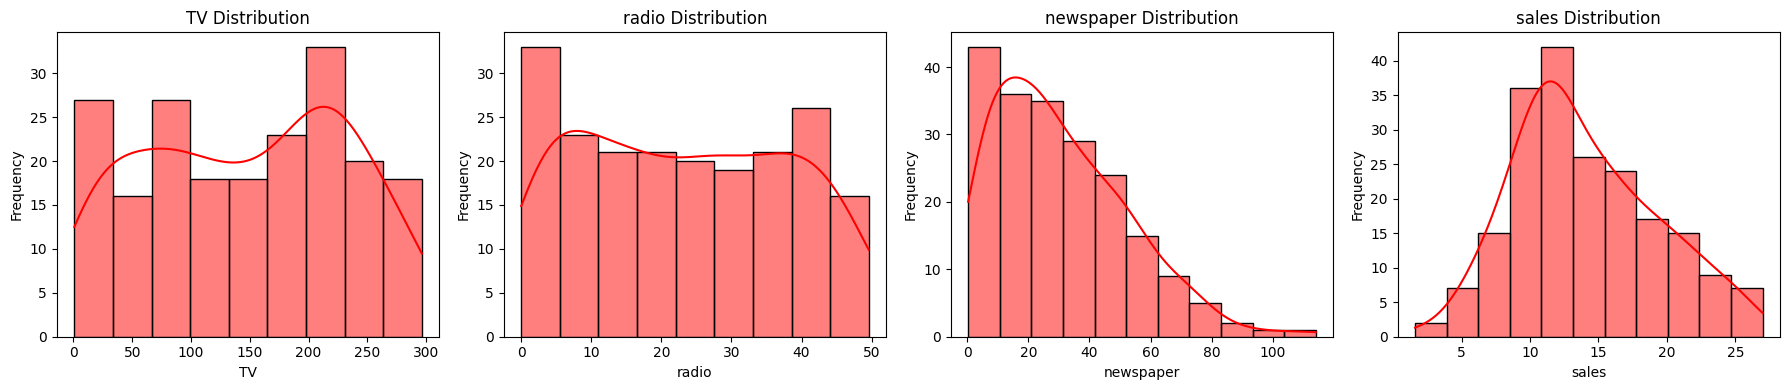

In [5]:
# histogram with KDE fro each feature to check distribution of shape and potential
fig, axes=plt.subplots(1,4, figsize=(18,4))
for i,col in enumerate(df.columns):
  sns.histplot(df[col], kde=True, ax=axes[i], color='red', edgecolor='black')
  axes[i].set_title(f'{col} Distribution')
  axes[i].set_xlabel(col)
  axes[i].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

# BOX Plot are the fastest way to check for outliars any point sitting far outside the whickers

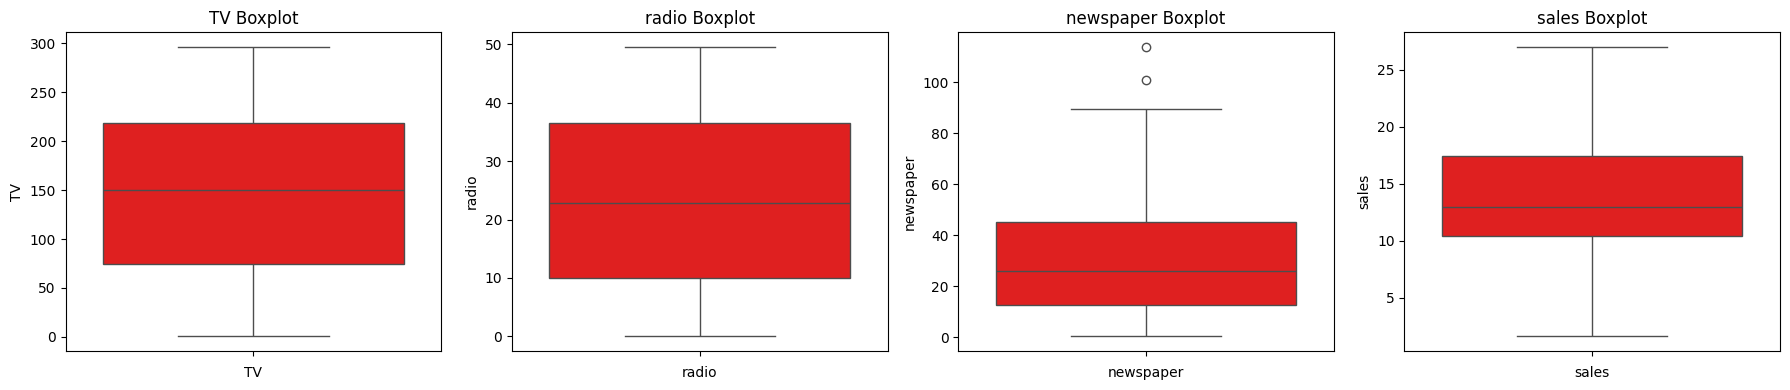

In [6]:
# boxplot to check for outliars and distribution shape
fig,axes=plt.subplots(1,4, figsize=(18,4))

for i, col in enumerate(df.columns):
  sns.boxplot(y=df[col], ax=axes[i], color='red')
  axes[i].set_title(f'{col} Boxplot')
  axes[i].set_xlabel(col)

plt.tight_layout()
plt.show()

# scatter plots -- feature vs sales

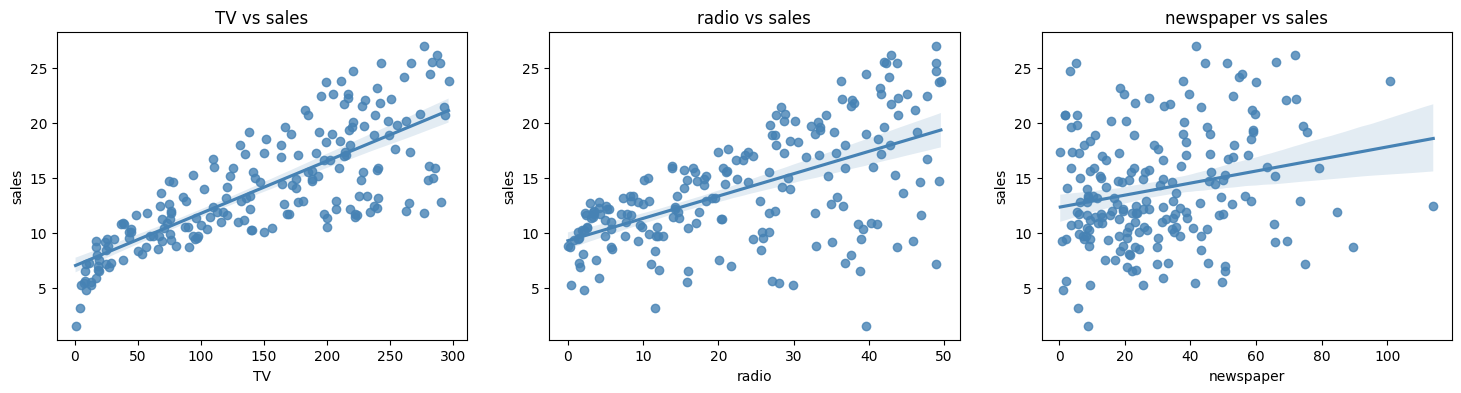

In [10]:
# scatterplot with each regression line for each feature vs target
features=df.columns[:-1]    # all the columns except the last one (slaes)
target=df.columns[-1]      # the last column (sales)

fig, axes=plt.subplots(1,3, figsize=(18,4))

for i, feature in enumerate(features):   # scatter plot + regression line
  sns.regplot(x=df[feature], y=df[target], ax=axes[i], color='steelblue')
  axes[i].set_title(f'{feature} vs {target}')
  axes[i].set_xlabel(feature)
  axes[i].set_ylabel(target)

plt.tight_layout()
plt.show()




 - Notice how TV show a clear positive trend with sales. Radio sales also trend upward though. This already hint that newspaper might not be strong predictor on its own.
 - Tv has strong relationship with sales column


## Correlation Matrix
- The correlation matrix quantifies what the scatterplot showed qualitatively. A values close

              TV  radio  newspaper  sales
TV         1.000  0.055      0.057  0.782
radio      0.055  1.000      0.354  0.576
newspaper  0.057  0.354      1.000  0.228
sales      0.782  0.576      0.228  1.000


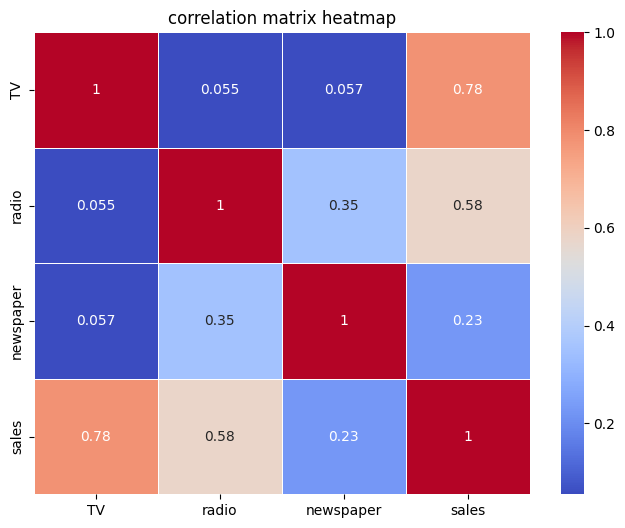

In [11]:
corr=df.corr().round(3)
print(corr)
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("correlation matrix heatmap")
plt.show()

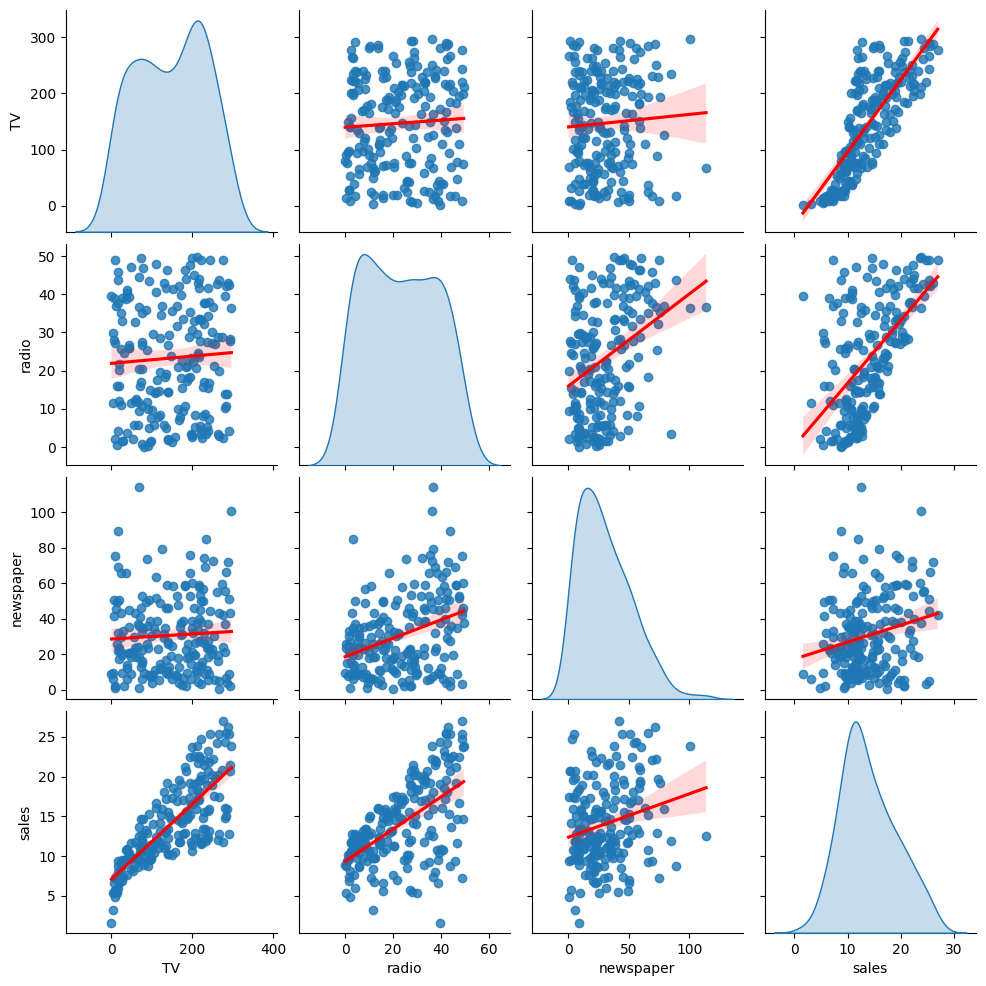

In [12]:
sns.pairplot(df,kind='reg', diag_kind='kde', plot_kws={'line_kws':{'color':'red'}})
plt.show()

# spliting the dataset


In [16]:
# features vs target

x=df[['TV','radio','newspaper']]
y=df['sales']

In [19]:
# 70 -30 train test split with a fixed random state for reproducibility
x_train,X_test,y_train,y_test=train_test_split(X,y , test_size=0.3, random_state=42) # 42 will kepp the data distribution same always

### Building the model
We will start with a **simple linear regression ** ( using tv , the strongest single prediction adding more prediction can improve -- or sometime not improve -- the model

# Simple linear regression (TV only)
The equation we are fitting is :
where  β₀ is the intercept (baseline sales when TV spend is Zero ) and β1 is the

In [21]:
#Simple linear regression using TV only
slr=LinearRegression()
slr.fit(x_train[['TV']],y_train)
y_pred_slr=slr.predict(X_test[['TV']])





In [23]:
print(y_pred_slr)  # inbuild method doesnt use gradient method it uses normal form
print(y_test) # true label

[14.81785392 16.30754437 20.83230507  7.78243112 17.46309864 10.72468577
 17.30067133  9.55984994 17.56055502 15.36546598  8.7013056   9.84757831
 18.12208943  7.49006196 13.71334823 15.13806775  7.57823679 16.40964153
 10.73396733 18.25667206 17.89005042 10.38590882  9.00295631 18.88317738
 10.44159818  9.72227724 17.14752559 13.70406667 11.28622018  7.62928537
 16.5117387  10.45087974 16.46997167  8.02375169 20.26612989 18.2937983
  9.48095667 19.94127527 12.67845424  8.51567439 12.62276488 15.45364081
  9.2396361  10.1306659  17.63480751  9.01223787 10.51585066 14.07532908
 12.09371593 10.78037513 10.86854996 15.05453371  7.64320771  7.60144069
 10.78501591 13.24462943 10.64579251 20.68380011  8.14905275 16.40964153]
96     16.9
16     22.4
31     21.4
159     7.3
129    24.7
116    12.6
70     22.3
171     8.4
175    11.5
46     14.9
67      9.5
183     8.7
166    11.9
79      5.3
187    10.3
178    11.7
57      5.5
153    16.6
83     11.3
69     18.9
125    19.7
17     12.5
149   

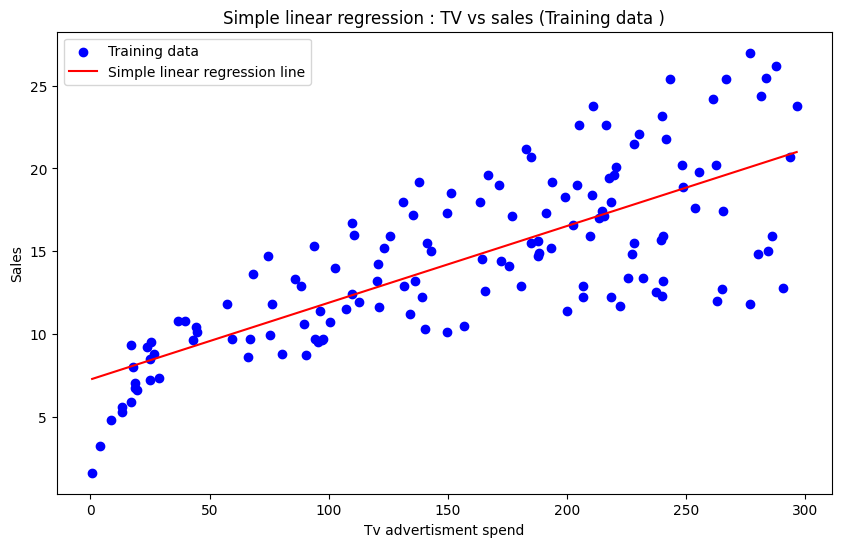

In [30]:
# visualize the simple regression line on the training data

plt.figure(figsize=(10,6))
plt.scatter(x_train['TV'],y_train, color='blue', label='Training data')
sns.lineplot(x=x_train['TV'], y=slr.intercept_+slr.coef_[0]*x_train['TV'], color='red', label='Simple linear regression line')
plt.title("Simple linear regression : TV vs sales (Training data )")

plt.xlabel("Tv advertisment spend")
plt.ylabel("Sales")
plt.legend()
plt.show()




In [31]:
#  evluate the simple model on the test set

mse_slr=mean_squared_error(y_test,y_pred_slr)
mae_slr=mean_absolute_error(y_test,y_pred_slr)
r2_slr=r2_score(y_test,y_pred_slr)

print("Simple __LR -- Test set performance --- ")
print(f"Mean squared error: {mse_slr:.4f}")
print(f"Mean absolute error: {mae_slr:.4f}")
print(f"R-squared: {r2_slr:.4f}")




Simple __LR -- Test set performance --- 
Mean squared error: 8.9710
Mean absolute error: 2.2759
R-squared: 0.6714


## 6.2 Multiple Linear regression
Now we use all three features. The equation becomens:

This should capture more of the variance in sales, especially since radio also

In [32]:
# multiple linear regression using all three features

mlr=LinearRegression()
mlr.fit(x_train,y_train)
y_pred_mlr=mlr.predict(X_test)


# They learned coefficient and intercept of the multiple linear regression


print("Multiple linear regression COefficient ")
print(f"Intercept (bets 0): {mlr.intercept_:.4f}")
for i,col in enumerate(x_train.columns):
  print(f"Coefficient (beta {i+1}): {mlr.coef_[i]:.4f} for {col}")


Multiple linear regression COefficient 
Intercept (bets 0): 2.7089
Coefficient (beta 1): 0.0441 for TV
Coefficient (beta 2): 0.1993 for radio
Coefficient (beta 3): 0.0069 for newspaper


## Model evaluation
- We evaluate the multiple regression model on the held out test set. The key matrices are:

  - R- Squared-- proportion of variance in sales explained by the model (1.0 perfect)
  - Mean Absolute error (MAE) -- average absolute diffrence between predicted and actual value
  - Root Mean Squared error(RMSE) -- like MAE but penalies larger errir more then heatmap
  

In [35]:
# Muliple LR _ Test Set performance
y_pred=mlr.predict(X_test)
mse_mlr=mean_squared_error(y_test,y_pred)
mae_mlr=mean_absolute_error(y_test,y_pred)
r2_mlr=r2_score(y_test,y_pred)


# print all the matrix together for easy comparision

print("Multiple Linear Regression -- Test set performance")
print(f"Mean squared error: {mse_mlr:.4f}")
print(f"Mean absolute error: {mae_mlr:.4f}")
print(f"R-squared: {r2_mlr:.4f}")
print(f"RMSE: { np.sqrt(mse_mlr):.4f}")


Multiple Linear Regression -- Test set performance
Mean squared error: 3.7968
Mean absolute error: 1.5117
R-squared: 0.8609
RMSE: 1.9485


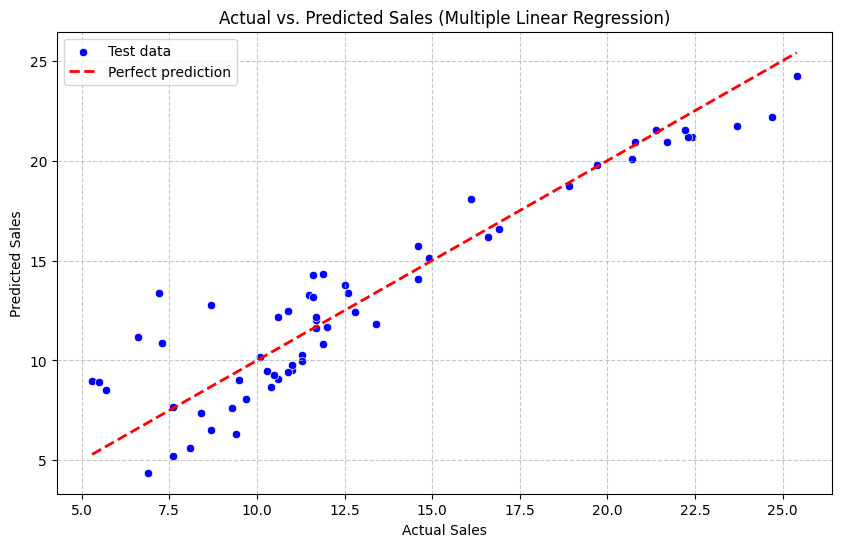

In [36]:
# actual and predicted sale ( Multiple LR ) plot
plt.figure(figsize=(10,6))
sns.scatterplot(x=y_test, y=y_pred, color='blue', label='Test data')
sns.lineplot(x=[y_test.min(),y_test.max()], y=[y_test.min(),y_test.max()], color='red', linewidth=2, linestyle='--', label='Perfect prediction')
plt.title('Actual vs. Predicted Sales (Multiple Linear Regression)')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

/tmp/ipykernel_2434/688940757.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=X.columns, y=mlr.coef_, palette='viridis')


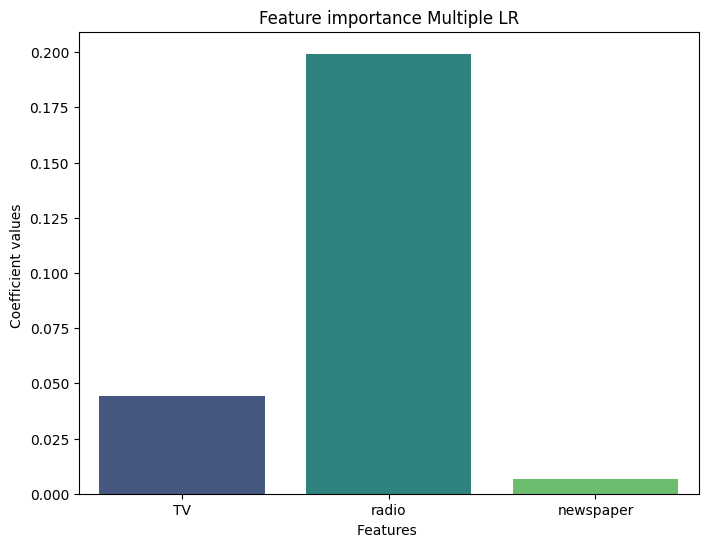

In [38]:
# ciefficient bar chart plot to visually compare the relative importnace of evaluation
plt.figure(figsize=(8,6))
sns.barplot(x=X.columns, y=mlr.coef_, palette='viridis')
plt.title("Feature importance Multiple LR")
plt.xlabel("Features ")
plt.ylabel("Coefficient values ")
plt.show()

## How to read the coefficient :
- Intercept (β₀): The intercept is 2.7089. This represents the estimated sales (in thousands of units) when the spending on TV, radio, and newspaper advertising is zero. In other words, if there's no advertising, the model predicts a baseline sales of approximately 2,709 units.

- TV Coefficient (β₁): The coefficient for 'TV' is 0.0441. This means that for every additional thousand dollars spent on TV advertising, the estimated sales are expected to increase by approximately 44.1 units, assuming that spending on radio and newspaper remains constant.

- Radio Coefficient (β₂): The coefficient for 'radio' is 0.1993. This indicates that for every additional thousand dollars spent on radio advertising, the estimated sales are expected to increase by approximately 199.3 units, holding TV and newspaper spending constant.

- Newspaper Coefficient (β₃): The coefficient for 'newspaper' is 0.0069. This suggests that for every additional thousand dollars spent on newspaper advertising, the estimated sales are expected to increase by approximately 6.9 units, assuming TV and radio spending remain constant. This value is quite small compared to TV and radio, reinforcing the earlier observation that newspaper advertising might not be as strong a predictor of sales in this model.